In [1]:
# Библиотека для работы с массивами
import numpy as np

# Библиотека для работы с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Для загрузки датасета
from torchvision.datasets import FashionMNIST

# Для красивого вывода таблиц в ноутбуке
from IPython.display import display

# Отрисовывать изображения в ноутбуке, а не в консоль или файл
%matplotlib inline



In [2]:
class Models:
  def __init__(self, epochs = 10, batch_size = 128):
    self.epochs = epochs
    self.batch_size = batch_size
    self.device = torch.device('cuda')

  def load_data(self):
    # Загрузка набора данных
    train_dataset = FashionMNIST(root='./data', train=True, download=True)
    test_dataset = FashionMNIST(root='./data', train=False, download=True)

    # Преобразование изображения 28х28 в вектор элементов
    x_train_full = train_dataset.data.reshape(60000, 784).float() / 255.0
    y_train_full = train_dataset.targets.long()

    x_test = test_dataset.data.reshape(10000, 784).float() / 255.0
    y_test = test_dataset.targets.long()

    # Деление выборки
    x_train = x_train_full[:50000] # обучающие
    y_train = y_train_full[:50000]

    x_val = x_train_full[50000:] # проверочные
    y_val = y_train_full[50000:]

    return x_train, y_train, x_val, y_val, x_test, y_test

  # создание модели
  def create_model(self, neurons):
    model = nn.Sequential(
        nn.Linear(784, neurons),
        nn.ReLU(),
        nn.Linear(neurons, 10)
    )

    return model.to(self.device)

  def train_model(self, model, x_train, y_train, x_val, y_val):
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = 0.001)

    history = {
        'accuracy': [],
        'val_accuracy': [],
        'loss': [],
        'val_loss': []
    }

    for epoch in range(self.epochs):
      model.train()
      permutation = torch.randperm(x_train.size(0))

      train_loss = 0
      train_correct = 0

      for i in range(0, x_train.size(0), self.batch_size):
        indices = permutation[i:i+self.batch_size]
        x_batch = x_train[indices].to(self.device)
        y_batch = y_train[indices].to(self.device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = loss_function(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)
        predicted = torch.argmax(outputs, dim = 1)
        train_correct += (predicted == y_batch).sum().item()

      train_loss = train_loss / x_train.size(0)
      train_accuracy = train_correct / x_train.size(0)

      model.eval()
      with torch.no_grad():
        x_val_device = x_val.to(self.device)
        y_val_device = y_val.to(self.device)

        val_outputs = model(x_val_device)
        val_loss = loss_function(val_outputs, y_val_device).item()
        val_predicted = torch.argmax(val_outputs, dim = 1)
        val_accuracy = (val_predicted == y_val_device).sum().item() / y_val.size(0)

      history['loss'].append(train_loss)
      history['accuracy'].append(train_accuracy)
      history['val_loss'].append(val_loss)
      history['val_accuracy'].append(val_accuracy)

      print(f"Эпоха {epoch + 1}/{self.epochs} - loss: {train_loss:.4f} - accuracy: {train_accuracy:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}")

    return history

  def evaluate_model(self, model, x_test, y_test):
    loss_function = nn.CrossEntropyLoss()

    model.eval()
    with torch.no_grad():
      x_test_device = x_test.to(self.device)
      y_test_device = y_test.to(self.device)

      outputs = model(x_test_device)
      loss_test = loss_function(outputs, y_test_device).item()
      predicted = torch.argmax(outputs, dim = 1)
      accuracy_test = (predicted == y_test_device).sum().item() / y_test.size(0)

    return loss_test, accuracy_test

  def results(self):
      # Получение данных
      x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()
      neuron_types = [32, 64, 128, 256, 512, 1024, 70, 150, 700]
      results = []
      history = {}

      # обучение
      for neurons in neuron_types:
        print('Количество нейронов в обучении: ', neurons)
        model = self.create_model(neurons)
        trained = self.train_model(model, x_train, y_train, x_val, y_val)

        # проверка качества на тестовой выборке
        loss_test, accuracy_test = self.evaluate_model(model, x_test, y_test)
        history[neurons] = trained

        results.append({
            "Нейроны": neurons,
            "Точность на обучающей выборке": trained['accuracy'][-1],
            "Точность на тестовой выборке": accuracy_test,
            "Точность на валидационной выборке": trained['val_accuracy'][-1],
            "Ошибка на обучающей выборке": trained['loss'][-1],
            "Ошибка на тестовой выборке": loss_test,
            "Ошибка на валидационной выборке": trained['val_loss'][-1]
            })

      df = pd.DataFrame(results)
      return df, history



In [3]:
m1 = Models(epochs = 10, batch_size = 128)
df, history = m1.results()



100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 174kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.76MB/s]


Количество нейронов в обучении:  32
Эпоха 1/10 - loss: 0.7526 - accuracy: 0.7524 - val_loss: 0.5261 - val_accuracy: 0.8143
Эпоха 2/10 - loss: 0.4772 - accuracy: 0.8350 - val_loss: 0.4644 - val_accuracy: 0.8378
Эпоха 3/10 - loss: 0.4301 - accuracy: 0.8497 - val_loss: 0.4278 - val_accuracy: 0.8489
Эпоха 4/10 - loss: 0.4070 - accuracy: 0.8573 - val_loss: 0.4135 - val_accuracy: 0.8547
Эпоха 5/10 - loss: 0.3914 - accuracy: 0.8626 - val_loss: 0.4196 - val_accuracy: 0.8508
Эпоха 6/10 - loss: 0.3797 - accuracy: 0.8668 - val_loss: 0.4022 - val_accuracy: 0.8598
Эпоха 7/10 - loss: 0.3702 - accuracy: 0.8693 - val_loss: 0.3868 - val_accuracy: 0.8648
Эпоха 8/10 - loss: 0.3633 - accuracy: 0.8708 - val_loss: 0.3948 - val_accuracy: 0.8630
Эпоха 9/10 - loss: 0.3547 - accuracy: 0.8746 - val_loss: 0.3860 - val_accuracy: 0.8631
Эпоха 10/10 - loss: 0.3472 - accuracy: 0.8773 - val_loss: 0.3793 - val_accuracy: 0.8661
Количество нейронов в обучении:  64
Эпоха 1/10 - loss: 0.6742 - accuracy: 0.7768 - val_loss: 

,Нейроны,Точность на обучающей выборке,Точность на тестовой выборке,Точность на валидационной выборке,Ошибка на обучающей выборке,Ошибка на тестовой выборке,Ошибка на валидационной выборке
0,32,0.87734,0.8578,0.8661,0.347182,0.400886,0.379338
1,64,0.88836,0.8641,0.8712,0.313594,0.388768,0.366910
2,128,0.89852,0.8727,0.8808,0.281462,0.359539,0.336998
3,256,0.90738,0.8809,0.8879,0.254989,0.334547,0.308080
4,512,0.91190,0.8755,0.8836,0.238350,0.344841,0.321640
5,1024,0.91790,0.8807,0.8867,0.223254,0.347102,0.320932
6,70,0.88952,0.8633,0.8716,0.306299,0.390053,0.367283
7,150,0.89916,0.8706,0.8757,0.275734,0.363442,0.345295
8,700,0.91406,0.8864,0.8929,0.230284,0.326040,0.302156


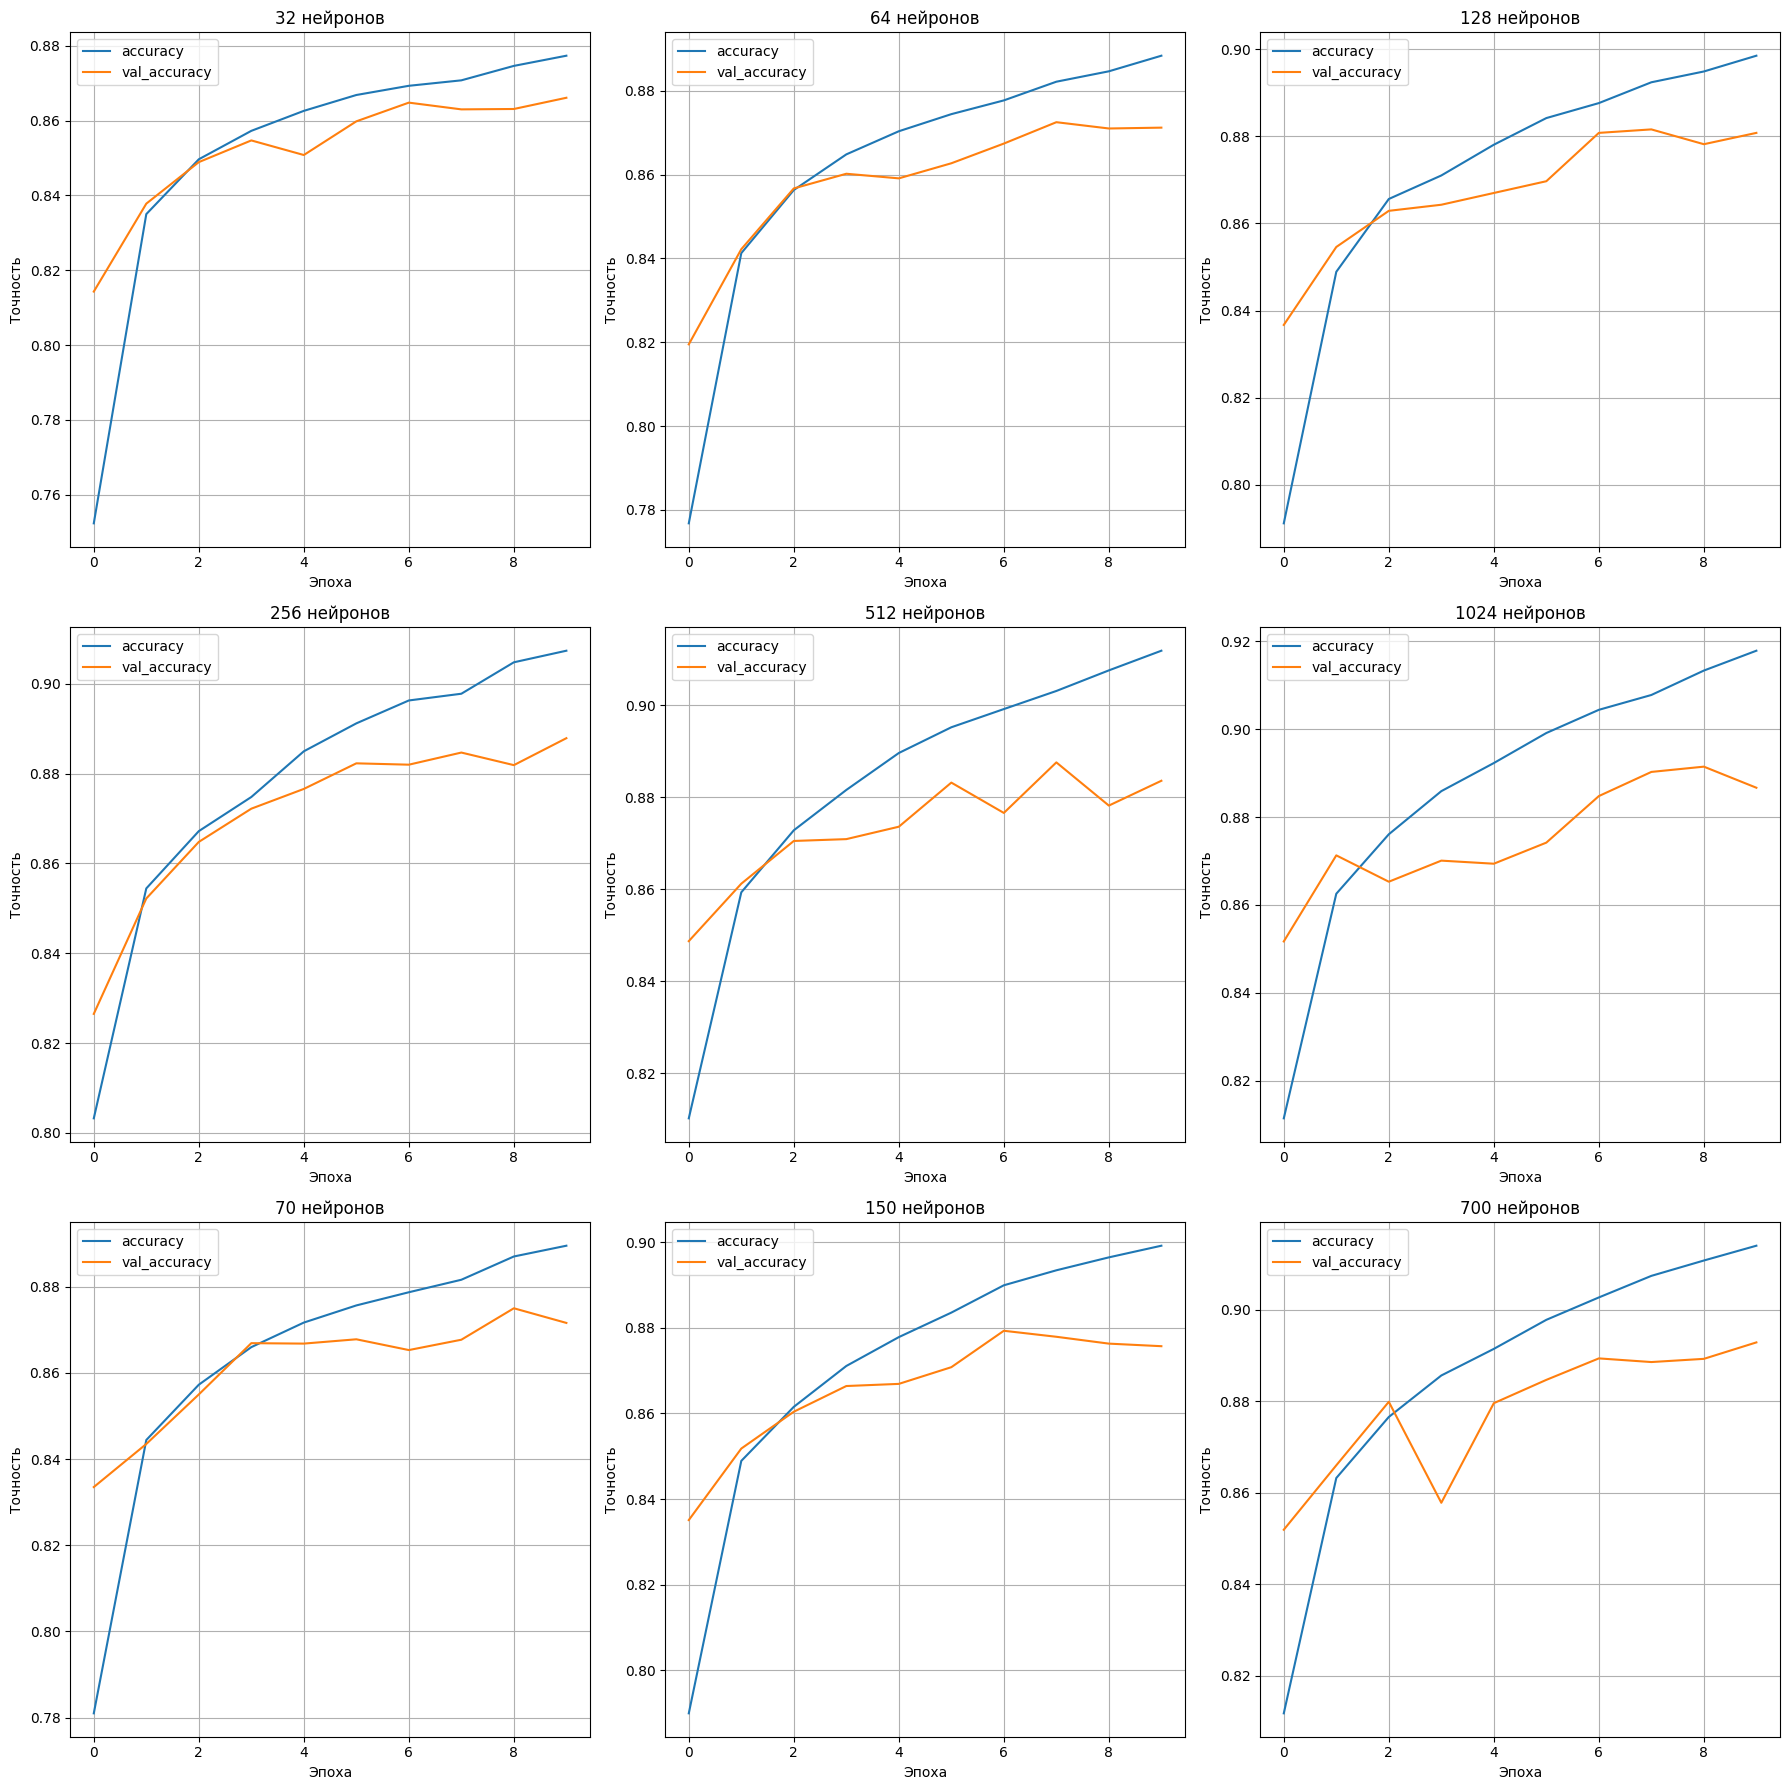

In [4]:
display(df)

neuron_types = [32, 64, 128, 256, 512, 1024, 70, 150, 700]

fig,axs = plt.subplots(3, 3, figsize = (18, 18))
for i, neurons in enumerate(neuron_types):
  row = i // 3
  col = i % 3

  axs[row, col].set_title(f'{neurons} нейронов')
  axs[row, col].plot(history[neurons]['accuracy'], label = 'accuracy')
  axs[row, col].plot(history[neurons]['val_accuracy'], label = 'val_accuracy')
  axs[row, col].set_xlabel('Эпоха')
  axs[row, col].set_ylabel('Точность')
  axs[row, col].legend()
  axs[row, col].grid(True)

plt.tight_layout()
plt.show()

